 # WIDE & DEEP NEURAL COLLABORATIVE FILTERING (NCF)

## CELL 1: Install & verify

PyTorch is imported and asked to report what it can see: the library version (important for verifying compatibility with specific APIs used later), whether CUDA is available, and if so, the name of the device and how much video memory it carries.

A device object is also created here. Every subsequent tensor operation will reference it, so storing torch.device('cuda') or torch.device('cpu') once means we never have to sprinkle conditional logic throughout the rest of the notebook.


In [ ]:
import subprocess, sys

# Confirm GPU is available
import torch

CUDA_AVAILABLE = torch.cuda.is_available()

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {CUDA_AVAILABLE}")
if CUDA_AVAILABLE:
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  NO GPU. Go to: Runtime -> Change runtime type -> T4 GPU")

device = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## CELL 2: Imports

All external dependencies are consolidated here rather than scattered across cells. If any library is missing or misnamed, the error surfaces immediately instead of appearing as a cryptic NameError buried inside a training loop an hour later.

The imports fall into a few natural groups. The PyTorch family (torch, torch.nn, torch.optim, torch.utils.data) provides the backbone of the entire model: layers, loss functions, optimisers, and the data pipeline. NumPy handles fast array arithmetic; Pandas loads and manipulates the ratings table as a structured dataframe. Matplotlib and Seaborn handle visualisation, with Seaborn's whitegrid style set globally so all plots share a consistent aesthetic. LabelEncoder from scikit-learn maps raw user and movie IDs (arbitrary integers with gaps) onto the compact, zero-based integer sequences that PyTorch's Embedding layers require. The standard library (collections, warnings, os, io, zipfile, requests) covers dataset downloading, deprecation warning suppression, and various utility tasks.

Random seeds are fixed to 42 for both PyTorch and NumPy. Weight initialisation, data shuffling, and negative sampling all involve randomness, and fixing the seed ensures the notebook produces the same result every time it is run from scratch. That consistency is a prerequisite for reliable debugging and fair result comparisons.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import warnings, os, io, zipfile, requests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("All imports successful.")

All imports successful.


## CELL 3: Data loading

The MovieLens dataset is the standard benchmark for recommender systems research. Two versions are supported, controlled by the DATASET variable at the top of the cell.

The "1M" option loads approximately one million ratings from 6,000 users across 4,000 movies, collected by GroupLens up to the year 2000. It is compact and fast, ideal for experimentation and iteration. The "25M" option is a much larger and more recent corpus. Training takes significantly longer but produces more robust embeddings.

The 1M dataset uses a pipe-delimited .dat format common in the early 2000s. The sep='::' argument and engine='python' are both required because the default C parser cannot handle multi-character separators. The 25M dataset is a standard CSV and loads with default settings.

After loading, the cell prints the number of ratings, distinct movies, and distinct users. These counts determine the size of the model's embedding tables (one row per user, one row per movie), so confirming them now prevents silent dimension mismatches later.

In [ ]:
# The loader handles both formats automatically.

DATASET = "1M"

if DATASET == "1M":
    if not os.path.exists('ml-1m'):
        print("Downloading MovieLens 1M...")
        r = requests.get('https://files.grouplens.org/datasets/movielens/ml-1m.zip')
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall('.')
        print("Done.")
    ratings = pd.read_csv(
        'ml-1m/ratings.dat', sep='::',
        names=['userId', 'movieId', 'rating', 'timestamp'],
        engine='python'
    )
    movies = pd.read_csv(
        'ml-1m/movies.dat', sep='::',
        names=['movieId', 'title', 'genres'],
        engine='python', encoding='latin-1'
    )

elif DATASET == "25M":
    if not os.path.exists('ml-25m'):
        print("Downloading MovieLens 25M (this takes a few minutes)...")
        r = requests.get('https://files.grouplens.org/datasets/movielens/ml-25m.zip')
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall('.')
        print("Done.")
    ratings = pd.read_csv('ml-25m/ratings.csv')
    movies  = pd.read_csv('ml-25m/movies.csv')
    # 25M doesn't have a genres column with pipe-separated values; it's the same format
    # but the tag genome is separate. The movies.csv uses the same schema.

print(f"Ratings : {ratings.shape[0]:,} rows")
print(f"Movies  : {movies.shape[0]:,} rows")
print(f"Users   : {ratings['userId'].nunique():,}")

Ratings : 1,000,209 rows
Movies  : 3,883 rows
Users   : 6,040


## CELL 4: Preprocessing

Four distinct preprocessing steps happen here, each solving a concrete problem.

ID Encoding. PyTorch's Embedding layer is a lookup table indexed by integers. It requires those integers to be contiguous and zero-based (0, 1, 2, to N minus 1). The original MovieLens user and movie IDs are arbitrary numbers with gaps: user 1 may be followed by user 3, skipping 2 entirely. LabelEncoder from scikit-learn fixes this by sorting all unique IDs and mapping them to a clean sequential range. The encoded indices are written back into the dataframe as user_idx and movie_idx.

Genre Encoding. Each movie carries a pipe-separated genre string like "Action|Adventure|Sci-Fi". That string is not usable as a numerical input. The cell defines an 18-dimensional binary genre vocabulary (one dimension per genre in the MovieLens taxonomy) and converts every movie's genre string into a vector of ones and zeros. This genre_matrix (one row per movie) is the "wide" feature input the model's architecture will consume alongside learned embeddings.

Temporal Train/Test Split. A naive random split leaks future information into the training set, making evaluation metrics artificially optimistic. Sorting the ratings table by timestamp and using the earliest 80% for training and the latest 20% for testing preserves temporal ordering. This more faithfully simulates real-world conditions: train on historical behaviour, evaluate on future behaviour.

Popularity Array. A normalised popularity score is computed for each movie from training data: the count of ratings it received, divided by the maximum count so all scores land in [0, 1]. This array is not used during neural network training. It becomes a lightweight tiebreaker in the cold-start recommendation path, where no personalised signal is available.

In [ ]:
# PyTorch Embedding layers require contiguous integer indices starting at 0.
# LabelEncoder maps your original IDs (which may have gaps) to that range.

user_enc  = LabelEncoder()
movie_enc = LabelEncoder()

ratings['user_idx']  = user_enc.fit_transform(ratings['userId'])
ratings['movie_idx'] = movie_enc.fit_transform(ratings['movieId'])

n_users  = ratings['user_idx'].nunique()
n_movies = ratings['movie_idx'].nunique()
print(f"n_users={n_users:,}  n_movies={n_movies:,}")

ALL_GENRES = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]
N_GENRES = len(ALL_GENRES)

def encode_genres(genre_str: str) -> list:
    genres = set(genre_str.split('|'))
    return [1.0 if g in genres else 0.0 for g in ALL_GENRES]

movies['genre_vec'] = movies['genres'].apply(encode_genres)

movie_id_to_idx = {mid: idx for idx, mid in enumerate(movie_enc.classes_)}
genre_matrix = np.zeros((n_movies, N_GENRES), dtype=np.float32)
for _, row in movies.iterrows():
    if row['movieId'] in movie_id_to_idx:
        genre_matrix[movie_id_to_idx[row['movieId']]] = row['genre_vec']

print(f"Genre matrix shape: {genre_matrix.shape}")

# Temporal split
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(ratings_sorted) * 0.8)
train_df  = ratings_sorted.iloc[:split_idx].copy()
test_df   = ratings_sorted.iloc[split_idx:].copy()
print(f"Train : {len(train_df):,}  |  Test : {len(test_df):,}")

# Normalised to [0,1] so it can be added as a tiebreaker on a common scale.
popularity_counts = train_df['movie_idx'].value_counts()
pop_array = np.zeros(n_movies, dtype=np.float32)
for midx, count in popularity_counts.items():
    pop_array[midx] = count
pop_max = pop_array.max()
if pop_max > 0:
    pop_array /= pop_max
print(f"Popularity array built (max raw count: {int(pop_max):,} ratings)")

n_users=6,040  n_movies=3,706
Genre matrix shape: (3706, 18)
Train : 800,167  |  Test : 200,042
Popularity array built (max raw count: 2,902 ratings)


## CELL 5: PyTorch Dataset & DataLoader

The MovieLensDataset class wraps the dataframe into a format PyTorch can consume. Its constructor converts the relevant columns (user indices, movie indices, ratings, and genre vectors) into tensors once, upfront. The __getitem__ method returns a single sample by index and __len__ reports the total count. This is the minimal interface PyTorch's DataLoader requires.

The DataLoader sits on top of the dataset and handles batching and parallelism automatically. Rather than feeding the model one rating at a time (too slow) or all ratings at once (too much memory), it groups samples into mini-batches of 2,048. That size gives stable gradient estimates while fitting comfortably in GPU memory. The training loader shuffles the data each epoch so the model does not memorise the order of samples; the test loader does not shuffle, since evaluation order does not affect correctness.

Two additional settings are worth noting. When pin_memory is True, data is loaded into page-locked CPU memory, which allows the CUDA driver to transfer it to GPU memory faster. num_workers spawns background processes that pre-fetch the next batch while the GPU is busy processing the current one, hiding I/O latency.

After this cell, the data is fully prepared and can be iterated over in training loops without any further transformation.

In [ ]:
# DataLoader streams data in mini-batches directly from RAM → GPU.
# This is how 25M ratings is handled without loading everything at once.

class MovieLensDataset(Dataset):
    def __init__(self, df: pd.DataFrame, genre_matrix: np.ndarray):
        self.users   = torch.LongTensor(df['user_idx'].values)
        self.movies  = torch.LongTensor(df['movie_idx'].values)
        self.ratings = torch.FloatTensor(df['rating'].values)
        self.genres  = torch.FloatTensor(genre_matrix[df['movie_idx'].values])

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return (self.users[idx], self.movies[idx],
                self.ratings[idx], self.genres[idx])

BATCH_SIZE = 2048
NUM_WORKERS = 2 if CUDA_AVAILABLE else 0

train_dataset = MovieLensDataset(train_df, genre_matrix)
test_dataset  = MovieLensDataset(test_df,  genre_matrix)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=CUDA_AVAILABLE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=CUDA_AVAILABLE)

print(f"Train batches : {len(train_loader):,}")
print(f"Test  batches : {len(test_loader):,}")


Train batches : 391
Test  batches : 98


## CELL 6: Model Definition

The model is called WideAndDeepNCF, and its design draws from two influential ideas in the recommender systems literature.

The Wide component is a shallow linear layer that takes the genre feature vector directly as input and outputs a scalar score. Its power comes from memorisation: it can quickly learn that Action genres tend to receive higher predicted ratings from certain users. Wide models are fast to train and highly interpretable, but they cannot generalise to unseen combinations of features.

The Deep component is a multi-layer perceptron (MLP) that takes the concatenation of the user embedding and movie embedding as input, then passes it through a sequence of fully connected layers with LayerNorm, GELU activations, and Dropout. The MLP learns non-linear, higher-order interactions between users and items: the kind of latent relationships that explain why a user who loved one cult classic might also enjoy a very different film. This is the generalisation half of the architecture.

Embeddings and Biases. Every user and every movie gets a dense vector representation (an embedding) that the model learns during training, living in a 64-dimensional space. Each user and movie also gets a scalar bias term, and a single global bias is shared across all predictions. These bias terms account for the fact that some users habitually rate high, some movies consistently attract higher ratings, and the average rating across the dataset is not zero.

The Attention Scorer computes a scaled dot-product between a transformed version of the user embedding (the "query") and the movie embedding (the "key"). This single scalar, called attn, measures how strongly this user-movie pair is aligned in embedding space. It serves two roles: an auxiliary training signal (see Cell 7) and an interpretability output that can be surfaced to end users.

The learnable blending weight alpha is a scalar parameter wrapped in a sigmoid to keep it between 0 and 1. It controls the trade-off between the deep MLP score and the wide linear score. Rather than fixing this ratio by hand, the model learns the optimal blend from data.

The forward pass combines all these components: the deep and wide scores are blended by alpha, the user and movie biases are added, the global bias is added, and the result passes through a sigmoid and is rescaled to the [1, 5] range to match the MovieLens rating scale.

Weight initialisation uses small normal noise for the embedding tables (to break symmetry without large initial values) and Xavier uniform initialisation for the wide linear layer, which has a different optimal scale because it connects to a single output neuron.

In [ ]:
# Self-contained: redefines device and config constants so this cell can be
# run independently after a Colab kernel restart without hitting NameErrors.

import torch, torch.nn as nn
CUDA_AVAILABLE = torch.cuda.is_available()
device         = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')
EMBED_DIM      = 64
MLP_LAYERS     = (256, 128, 64)
DROPOUT        = 0.3


class AttentionScorer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W_q   = nn.Linear(dim, dim, bias=False)
        self.W_k   = nn.Linear(dim, dim, bias=False)
        self.scale = dim ** 0.5

    def forward(self, user_emb, movie_emb):
        q = self.W_q(user_emb)
        k = self.W_k(movie_emb)
        return (q * k).sum(dim=-1) / self.scale


class WideAndDeepNCF(nn.Module):
    def __init__(self, n_users, n_movies, n_genres,
                 embed_dim=64, mlp_layers=(256, 128, 64), dropout=0.3):
        super().__init__()

        self.user_emb    = nn.Embedding(n_users,  embed_dim)
        self.movie_emb   = nn.Embedding(n_movies, embed_dim)
        self.user_bias   = nn.Embedding(n_users,  1)
        self.movie_bias  = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        layers, in_dim = [], embed_dim * 2
        for out_dim in mlp_layers:
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_dim = out_dim
        self.deep_mlp    = nn.Sequential(*layers)
        self.deep_out    = nn.Linear(mlp_layers[-1], 1)
        self.wide_linear = nn.Linear(n_genres, 1, bias=True)
        self.attention   = AttentionScorer(embed_dim)
        self.alpha       = nn.Parameter(torch.tensor(0.5))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        nn.init.xavier_uniform_(self.wide_linear.weight)

    def forward(self, user, movie, genres, return_attention=False):
        u  = self.user_emb(user)
        m  = self.movie_emb(movie)
        ub = self.user_bias(user).squeeze(1)
        mb = self.movie_bias(movie).squeeze(1)

        deep_score = self.deep_out(
            self.deep_mlp(torch.cat([u, m], dim=1))
        ).squeeze(1)
        wide_score = self.wide_linear(genres).squeeze(1)
        attn       = self.attention(u, m)

        a      = torch.sigmoid(self.alpha)
        raw    = a * deep_score + (1 - a) * wide_score + ub + mb + self.global_bias
        rating = torch.sigmoid(raw) * 4 + 1

        cosine_target = (
            nn.functional.cosine_similarity(u.detach(), m.detach(), dim=1) + 1
        ) / 2

        if return_attention:
            return rating, attn
        return rating, cosine_target, attn


model = WideAndDeepNCF(
    n_users=n_users, n_movies=n_movies, n_genres=N_GENRES,
    embed_dim=EMBED_DIM, mlp_layers=MLP_LAYERS, dropout=DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(model)


Model parameters : 716,840
WideAndDeepNCF(
  (user_emb): Embedding(6040, 64)
  (movie_emb): Embedding(3706, 64)
  (user_bias): Embedding(6040, 1)
  (movie_bias): Embedding(3706, 1)
  (deep_mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (deep_out): Linear(in_features=64, out_features=1, bias=True)
  (wide_linear): Linear(in_features=18, out_features=1, bias=True)
  (attention): AttentionScorer(
    (W_q): Linear(in_features=64

## CELL 7: Training utilities

Two functions are defined here and will be called repeatedly during the training loop: train_one_epoch and evaluate.

`train_one_epoch` iterates over every mini-batch in the training DataLoader and runs the standard PyTorch training cycle: zero the gradients, compute the forward pass, compute the loss, backpropagate, clip gradients, and step the optimiser.

The loss has two components. The primary objective is MSE loss on the predicted ratings versus the true ratings: predicted scores should be close to what users actually gave. The auxiliary component is BCE loss on the attention logit versus a cosine similarity target. The attention score is trained to be high when the user and movie embeddings point in roughly the same direction in embedding space, encouraging the attention mechanism to be meaningful rather than arbitrary. This acts as a regulariser on the embedding geometry. The AUX_WEIGHT of 0.1 keeps this term from overwhelming the primary objective.

Mixed precision training (torch.cuda.amp.autocast) runs the forward pass in 16-bit floating point where possible. The GradScaler adjusts gradient magnitudes to prevent underflow. Together these roughly halve memory usage and accelerate computation on modern NVIDIA GPUs without reducing final accuracy.

Gradient clipping (clip_grad_norm_ with max_norm=1.0) guards against occasional exploding gradients, a known instability in deep networks. It rescales the gradient vector if its norm exceeds 1. This costs almost nothing and prevents rare but catastrophic training failures.

`evaluate` runs the model in inference mode (torch.no_grad(), model.eval()) over the test set, collects all predictions and targets, and computes RMSE and MAE. return_attention=True is passed to the model so it returns only the two values the evaluation function needs, skipping the cosine target computation that is only relevant during training.

In [ ]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()
AUX_WEIGHT = 0.1


def train_one_epoch(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    total_loss = 0.0
    for users, movies_b, ratings_b, genres in loader:
        users, movies_b = users.to(device), movies_b.to(device)
        ratings_b, genres = ratings_b.to(device), genres.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            preds, cosine_target, attn = model(users, movies_b, genres)
            loss = mse_loss(preds, ratings_b) + AUX_WEIGHT * bce_loss(attn, cosine_target)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item() * len(users)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for users, movies_b, ratings_b, genres in loader:
        users, movies_b = users.to(device), movies_b.to(device)
        genres = genres.to(device)
        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            preds, _ = model(users, movies_b, genres, return_attention=True)
        all_preds.append(preds.cpu())
        all_targets.append(ratings_b)
    p = torch.cat(all_preds)
    t = torch.cat(all_targets)
    return {
        'rmse': torch.sqrt(torch.mean((p - t) ** 2)).item(),
        'mae' : torch.mean(torch.abs(p - t)).item()
    }

## CELL 8: Training loop

All the components from previous cells (the model, the dataloaders, the loss functions, and the training utilities) come together here.

AdamW is the optimiser of choice. It is a variant of Adam with a corrected implementation of weight decay, which penalises large parameter values rather than folding decay into the gradient update. This is the mathematically proper form of L2 regularisation, and it helps prevent overfitting by keeping the model from memorising training examples at the expense of generalisation. The value 1e-2 is moderately strong regularisation for a model of this size.

OneCycleLR is a learning rate scheduler that follows a characteristic shape: a brief linear warm-up phase covering the first 10% of training steps, a peak, and then a long cosine decay toward a very small learning rate. This schedule typically produces better generalisation than a fixed learning rate and often converges in fewer epochs than more conservative approaches.

Early stopping monitors validation RMSE after each epoch. If RMSE improves, the best model weights are saved in CPU memory (to avoid holding an extra copy on the GPU). If RMSE does not improve for PATIENCE=5 consecutive epochs, training halts. This prevents continued training past the point of best generalisation, a phenomenon known as overfitting, while also avoiding wasted computation if the model has already converged.

At the end of training, the best weights are loaded back into the model, ensuring all subsequent cells work with the best version found during training rather than the weights from the final epoch.

In [ ]:
N_EPOCHS     = 20
PATIENCE     = 5
LR           = 1e-3
WEIGHT_DECAY = 1e-2

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=N_EPOCHS,
    pct_start=0.1,
)
scaler = torch.cuda.amp.GradScaler(enabled=CUDA_AVAILABLE)

history = {'train_loss': [], 'val_rmse': [], 'val_mae': [], 'lr': []}
best_rmse, best_state = float('inf'), None
epochs_no_improve = 0

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val RMSE':>10} {'Val MAE':>10}  Status")
print("-" * 60)

for epoch in range(1, N_EPOCHS + 1):
    loss    = train_one_epoch(model, train_loader, optimizer, scaler, scheduler)
    metrics = evaluate(model, test_loader)

    history['train_loss'].append(loss)
    history['val_rmse'].append(metrics['rmse'])
    history['val_mae'].append(metrics['mae'])
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if metrics['rmse'] < best_rmse:
        best_rmse         = metrics['rmse']
        best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        tag = "best"
    else:
        epochs_no_improve += 1
        tag = f"no improvement {epochs_no_improve}/{PATIENCE}"

    print(f"{epoch:>6d} {loss:>12.4f} {metrics['rmse']:>10.4f} {metrics['mae']:>10.4f}  {tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered. Best Val RMSE {best_rmse:.4f} was at a prior epoch.")
        break

model.load_state_dict(best_state)
model.to(device)
print(f"\nBest Val RMSE : {best_rmse:.4f}")

 Epoch   Train Loss   Val RMSE    Val MAE  Status
------------------------------------------------------------
     1       1.1445     0.9591     0.7620  best
     2       0.9051     0.9559     0.7540  best
     3       0.8712     0.9530     0.7492  best
     4       0.8429     0.9491     0.7497  best
     5       0.8254     0.9507     0.7511  no improvement 1/5
     6       0.8135     0.9514     0.7502  no improvement 2/5
     7       0.8025     0.9544     0.7527  no improvement 3/5
     8       0.7915     0.9539     0.7508  no improvement 4/5
     9       0.7774     0.9547     0.7510  no improvement 5/5

Early stopping triggered. Best Val RMSE 0.9491 was at a prior epoch.

Best Val RMSE : 0.9491


## CELL 9: Training curves

Three side-by-side plots are generated here, giving an immediate visual read of what happened during training.

The Training Loss plot shows how the combined MSE plus auxiliary BCE loss evolved across epochs. A healthy curve descends steadily in the early epochs and then plateaus. A curve that never decreases suggests a misconfigured learning rate or a bug in the loss computation. One that decreases but stays very high suggests underfitting. One that drops quickly and then starts rising on the validation plot suggests overfitting.

Validation Metrics overlays RMSE and MAE across epochs, with a vertical dashed line marking the epoch where RMSE was lowest. That is the epoch whose weights were saved by early stopping. RMSE penalises large errors more heavily than MAE (because errors are squared before averaging), so RMSE is typically higher than MAE and more sensitive to outlier predictions. Both should decline over training and stabilise.

The Learning Rate Schedule shows the OneCycleLR curve. The rate should rise during warm-up, peak, and then decay smoothly. If training stopped early, the curve will be truncated. That is expected behaviour, not a problem.

Together, these three plots let you quickly diagnose whether the model trained well, converged too slowly, overfit, or stopped prematurely.

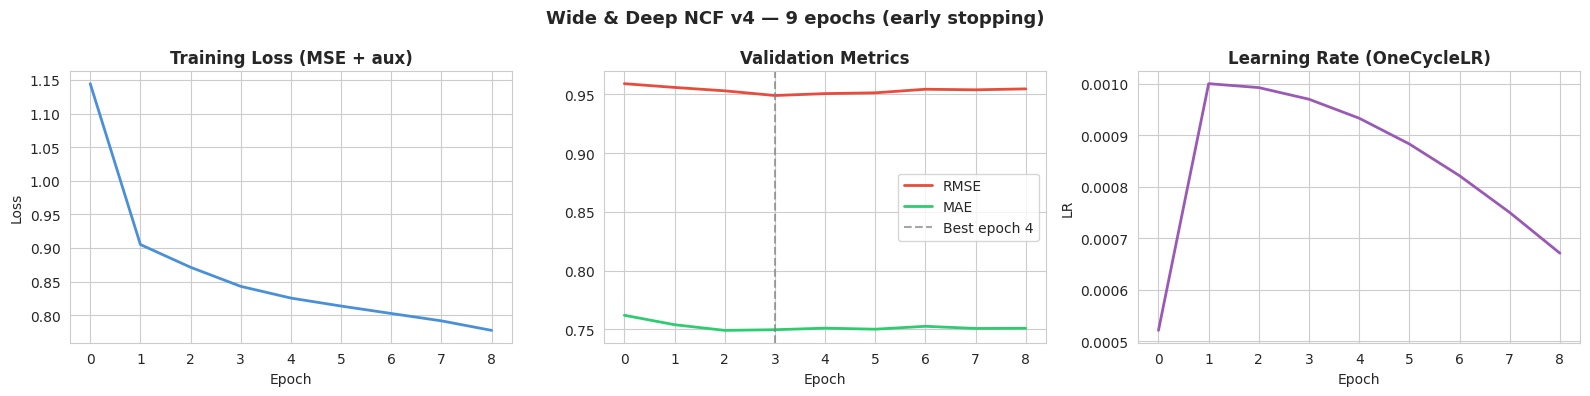

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_run = len(history['train_loss'])

axes[0].plot(history['train_loss'], color='#4A90D9', linewidth=2)
axes[0].set_title('Training Loss (MSE + aux)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(history['val_rmse'], color='#E74C3C', label='RMSE', linewidth=2)
axes[1].plot(history['val_mae'],  color='#2ECC71', label='MAE',  linewidth=2)
best_ep = history['val_rmse'].index(min(history['val_rmse']))
axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch {best_ep+1}')
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['lr'], color='#9B59B6', linewidth=2)
axes[2].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.suptitle(f'Wide & Deep NCF v4 — {epochs_run} epochs (early stopping)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## CELL 10: Ranking metrics Precision@K, Recall@K

A user does not care whether the model predicted 3.8 or 4.1 for a movie they will love. They care whether that movie appears in the top 10 results they actually see. This cell measures how well the model performs as a ranking system, not just a rating predictor.

For each sampled test user, the model generates predicted ratings for every movie that user has not yet seen in the training set. The top-K movies by predicted score are taken as the recommendations. A movie is considered "relevant" if the user rated it 3.5 or above in the test set, distinguishing genuine likes from indifferent or negative reactions.

Precision@K answers: of the K movies recommended, what fraction did the user actually like? A perfect score of 1.0 means every recommendation was relevant. It measures recommendation quality.

Recall@K answers: of all the movies the user liked in the test set, what fraction appeared in the top-K recommendations? It measures completeness. These two metrics trade off against each other: recommending more items increases recall but tends to decrease precision.

NDCG@K (Normalised Discounted Cumulative Gain) is the most sophisticated of the three. It asks not only whether relevant items appeared in the top-K list but also where. A relevant movie ranked first contributes more than one ranked tenth. The "discounted" part applies a logarithmic penalty to lower ranks; the "normalised" part divides by the ideal DCG, the score you would get if all relevant items appeared at the very top of the list. A score of 1.0 is perfect ordering; 0.0 means no relevant items appeared.

Because computing these metrics for all users is expensive, the cell samples 500 users at random: enough for a stable estimate without prohibitive computation time.

In [ ]:
import math

def _get_candidates_vectorised(uid, seen_dict, n_movies):
    mask = np.ones(n_movies, dtype=bool)
    seen = seen_dict.get(uid)
    if seen:
        # Includes the safety cast we added earlier
        seen_indices = [int(s) for s in seen if s < n_movies]
        mask[seen_indices] = False
    return np.where(mask)[0]

@torch.no_grad()
def evaluate_ranking_metrics(model, test_df, train_df, genre_matrix,
                             k=10, threshold=3.5, n_sample=500):
    model.eval()
    genre_t = torch.FloatTensor(genre_matrix).to(device)

    gt = defaultdict(set)
    seen = defaultdict(set)
    for _, row in test_df[test_df['rating'] >= threshold].iterrows():
        gt[row['user_idx']].add(row['movie_idx'])
    for _, row in train_df.iterrows():
        seen[row['user_idx']].add(row['movie_idx'])

    test_users = test_df['user_idx'].unique()
    sampled = np.random.choice(test_users, min(n_sample, len(test_users)), replace=False)

    precisions, recalls, ndcgs = [], [], []

    for uid in sampled:
        candidates = _get_candidates_vectorised(uid, seen, n_movies)
        if len(candidates) == 0 or uid not in gt:
            continue

        c_t = torch.LongTensor(candidates).to(device)
        u_t = torch.LongTensor([uid] * len(candidates)).to(device)
        g_t = genre_t[c_t]

        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            preds, _ = model(u_t, c_t, g_t, return_attention=True)

        top_k_idx = torch.topk(preds, min(k, len(candidates))).indices
        top_k_movies = c_t[top_k_idx].cpu().numpy()
        relevant_movies = gt[uid]

        # Precision & Recall
        hits = len(set(top_k_movies) & relevant_movies)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant_movies))

        # NDCG Calculation
        dcg = 0.0
        for rank, movie in enumerate(top_k_movies):
            if movie in relevant_movies:
                dcg += 1.0 / math.log2(rank + 2)

        idcg = 0.0
        for rank in range(min(len(relevant_movies), k)):
            idcg += 1.0 / math.log2(rank + 2)

        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcgs.append(ndcg)

    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(ndcgs))

print("Computing Precision@10, Recall@10, and NDCG@10 (500 user sample)...")
prec, rec, ndcg = evaluate_ranking_metrics(model, test_df, train_df, genre_matrix, k=10)

print(f"NCF Precision@10 : {prec:.4f}")
print(f"NCF Recall@10    : {rec:.4f}")
print(f"NCF NDCG@10      : {ndcg:.4f}")


Computing Precision@10, Recall@10, and NDCG@10 (500 user sample)...
NCF Precision@10 : 0.1470
NCF Recall@10    : 0.0359
NCF NDCG@10      : 0.1566


## CELL 11: Explainability

Recommender systems are often criticised as black boxes: they produce recommendations but cannot say why. This cell adds a lightweight but meaningful explanation layer on top of the model.

The explain_recommendation function takes a user ID and a movie ID, runs a single forward pass, and surfaces four pieces of human-readable information.

First, the movie's title and genre list: a basic sanity check that the correct movie was looked up. Second, the predicted rating: the model's estimate of how much this specific user would enjoy this specific movie, on the familiar 1 to 5 star scale. Third, the attention score: the output of the AttentionScorer passed through a sigmoid, yielding a value in [0, 1].

A high attention score means the user's embedding and the movie's embedding are strongly aligned in the latent space. A low score means the pairing is weak, and the prediction is driven more by the wide genre features or the bias terms. Fourth, a genre-based explanation: the wide linear layer has a weight for each genre, and multiplying those weights by the movie's binary genre vector gives a rough importance score per genre. The top genres by importance, filtered to only those the movie actually belongs to, become the plain-language explanation: "Recommended because your taste profile aligns with Action, Sci-Fi content."

This is not a perfect causal explanation. The MLP's deep representations are not directly inspectable. But it gives users a plausible, honest, and grounded reason for each recommendation rather than nothing at all.

The cell also handles the case where the user or movie ID is unknown (a cold-start situation) by printing an informative message rather than crashing.

In [ ]:
@torch.no_grad()
def explain_recommendation(user_original_id, movie_original_id):
    model.eval()
    if user_original_id not in user_enc.classes_:
        print(f"User {user_original_id} is a new (cold-start) user.")
        return
    if movie_original_id not in movie_enc.classes_:
        print(f"Movie {movie_original_id} not found.")
        return

    user_idx  = int(user_enc.transform([user_original_id])[0])
    movie_idx = int(movie_enc.transform([movie_original_id])[0])
    u_t = torch.LongTensor([user_idx]).to(device)
    m_t = torch.LongTensor([movie_idx]).to(device)
    g_t = torch.FloatTensor(genre_matrix[movie_idx:movie_idx+1]).to(device)

    with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
        rating, attn_logit = model(u_t, m_t, g_t, return_attention=True)

    attn_prob    = torch.sigmoid(attn_logit).item()
    genre_vec    = genre_matrix[movie_idx]
    wide_weights = model.wide_linear.weight.squeeze().detach().cpu().numpy()
    importance   = genre_vec * wide_weights
    top_idx      = np.argsort(importance)[::-1]
    top_genres   = [ALL_GENRES[i] for i in top_idx if genre_vec[i] > 0][:3]
    movie_row    = movies[movies['movieId'] == movie_original_id].iloc[0]

    print(f"  Movie     : {movie_row['title']}")
    print(f"  Genres    : {movie_row['genres']}")
    print(f"  Predicted : {rating.item():.2f} / 5.0")
    print(f"  Attention : {attn_prob:.3f}  (0=weak, 1=strong)")

    if top_genres:
        print(f"  Explanation: Recommended because your taste profile aligns with {', '.join(top_genres)} content.")


## CELL 12: Full recommendation pipeline

`get_nn_recommendations` takes a user's original ID (as it appears in the MovieLens dataset) and a desired list length, and returns a formatted dataframe of top recommendations.

The function first checks whether the user exists in the encoder. If not, it falls back to the cold-start path defined in the next cell. For known users, it identifies every movie they have already rated in the training set and excludes those from consideration. Recommending films the user has already seen wastes their top-K slots and makes the system look broken.

The remaining candidate movies are scored in a single forward pass rather than by looping through candidates one by one. The entire candidate set is batched into a single tensor and processed in parallel on the GPU, which is the efficient approach.

The top-N movies by predicted score are extracted, and for each one the function computes a simple genre-based explanation using the same wide-layer weight approach described in Cell 11. The output is a clean dataframe with columns for title, genres, predicted rating, attention score, and explanation: ready to be displayed to a user or consumed by a downstream application.

In [ ]:
@torch.no_grad()
def get_nn_recommendations(user_original_id: int, n: int = 10) -> pd.DataFrame:
    model.eval()

    if user_original_id not in user_enc.classes_:
        print(f"User {user_original_id} unknown — switching to cold-start.")
        return cold_start_recommendations(n=n)

    user_idx = int(user_enc.transform([user_original_id])[0])

    seen_set   = set(train_df[train_df['user_idx'] == user_idx]['movie_idx'].values)
    candidates = _get_candidates_vectorised(user_idx, {user_idx: seen_set}, n_movies)

    c_t = torch.LongTensor(candidates).to(device)
    u_t = torch.LongTensor([user_idx] * len(candidates)).to(device)
    g_t = torch.FloatTensor(genre_matrix[candidates]).to(device)

    with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
        preds, attn_logits = model(u_t, c_t, g_t, return_attention=True)

    preds_np = preds.cpu().numpy()
    attns_np  = torch.sigmoid(attn_logits).cpu().numpy()
    top_idx   = np.argsort(preds_np)[::-1][:n]
    wide_w    = model.wide_linear.weight.squeeze().detach().cpu().numpy()

    rows = []
    for i in top_idx:
        midx      = candidates[i]
        orig_id   = movie_enc.classes_[midx]
        movie_row = movies[movies['movieId'] == orig_id].iloc[0]
        gv        = genre_matrix[midx]
        top_genre_idx = np.argsort(gv * wide_w)[::-1]
        top_genre = next((ALL_GENRES[j] for j in top_genre_idx if gv[j] > 0), 'General')

        rows.append({
            'title'           : movie_row['title'],
            'genres'          : movie_row['genres'],
            'predicted_rating': round(float(preds_np[i]), 2),
            'attention_score' : round(float(attns_np[i]), 3),  # now a clean [0,1] probability
            'explanation'     : f"Because you enjoy {top_genre} content",
        })

    return pd.DataFrame(rows)


## CELL 13: Cold-start recommendations

How do you recommend anything useful to a brand-new user when you have no history to learn from? This is the cold-start problem, and this cell addresses it using a content-based approach that requires no user history at all.

The user's declared genre interests (for example, ["Sci-Fi", "Action"]) are encoded as a binary vector over the 18-genre vocabulary. Every movie in the catalogue also has such a vector, taken from the genre_matrix built in Cell 4. The function computes the cosine similarity between the user's preference vector and each movie's genre vector, which measures the angular alignment between them regardless of magnitude. A movie that is 100% Sci-Fi and Action scores a perfect 1.0 against a user who likes only those genres; a pure Romance film scores 0.

Movies with zero overlap are excluded. For the remaining candidates, a small popularity bonus (POP_WEIGHT * pop_array) is added as a secondary tiebreaker. Between two equally genre-relevant films, the more widely-seen one is surfaced first. That is a reasonable default when no personalised signal is available.

As the user rates items over time, future calls will gradually shift from this cold-start path to the full neural recommendation path

In [ ]:
def cold_start_recommendations(genre_preferences=None, n=10):
    if genre_preferences is None:
        genre_preferences = ['Drama', 'Comedy']

    pref_set = set(genre_preferences)
    pref_vec = np.array(
        [1.0 if g in pref_set else 0.0 for g in ALL_GENRES],
        dtype=np.float32
    )
    pref_norm = np.linalg.norm(pref_vec)
    if pref_norm == 0:
        print(f"No valid genres found. Valid names: {ALL_GENRES}")
        return pd.DataFrame()

    scores = []
    for midx in range(n_movies):
        gv = genre_matrix[midx]
        gv_norm = np.linalg.norm(gv)
        if gv_norm == 0:
            continue
        cosine_sim = float(np.dot(pref_vec, gv) / (pref_norm * gv_norm))

        if cosine_sim <= 0:
            continue

        # Popularity as a secondary tiebreaker, scaled down so it can't override a real genre-relevance difference
        final_score = cosine_sim + POP_WEIGHT * float(pop_array[midx])
        scores.append((midx, cosine_sim, final_score))

    if not scores:
        print(f"No movies found matching genres: {genre_preferences}")
        print(f"Valid genre names: {ALL_GENRES}")
        return pd.DataFrame()

    scores.sort(key=lambda x: x[2], reverse=True)

    rows = []
    for midx, cosine_sim, final_score in scores[:n]:
        orig_id   = movie_enc.classes_[midx]
        movie_row = movies[movies['movieId'] == orig_id].iloc[0]
        rows.append({
            'title'           : movie_row['title'],
            'genres'          : movie_row['genres'],
            'genre_match'     : round(cosine_sim, 4),   # interpretable signal
            'final_score'     : round(final_score, 4),
            'explanation'     : f"Based on your interest in: {', '.join(genre_preferences)}",
        })

    return pd.DataFrame(rows)

## CELL 13b: Cold-start sanity check

This cell runs a structured set of tests to verify that genre preferences actually drive the cold-start output, not just popularity.

Three test cases are defined: a user who prefers Sci-Fi and Action, a user who prefers only Drama, and a user who prefers Horror and Thriller. For each case, cold_start_recommendations is called, the top 10 results are taken, and the cell checks that every returned movie contains at least one of the requested genres in its genre string.

If all 10 recommendations match, the test is marked PASS. If some do not, a WARN is printed and the offending titles are listed. This catches subtle bugs: if the cosine similarity scoring had an error that ignored genre overlap entirely, the function might still return plausible-looking movies ranked by popularity alone, and this test would catch it.

Running this check each time the cell is executed takes only a second and gives confidence that the cold-start path is working correctly before the system is demonstrated or deployed.

In [ ]:
# Verifies that genre preferences actually dominate the output.
# If Sci-Fi/Action recs contain NO Sci-Fi or Action movies → broken.

print("COLD-START SANITY CHECK")

test_cases = [
    (['Sci-Fi', 'Action'],  {'Sci-Fi', 'Action'}),
    (['Drama'],              {'Drama'}),
    (['Horror', 'Thriller'], {'Horror', 'Thriller'}),
]

all_passed = True
for prefs, required_tags in test_cases:
    df = cold_start_recommendations(prefs, n=10)
    if df.empty:
        print(f"  FAIL [{prefs}] — returned 0 results")
        all_passed = False
        continue

    # Check that every recommendation contains at least one requested genre
    def has_overlap(genre_str):
        movie_genres = set(genre_str.split('|'))
        return bool(movie_genres & required_tags)

    overlap_count = df['genres'].apply(has_overlap).sum()
    pct = overlap_count / len(df) * 100

    status = "PASS" if overlap_count == len(df) else f"WARN ({overlap_count}/{len(df)} match)"
    print(f"  {status} — prefs={prefs}")
    if overlap_count < len(df):
        print(f"         Mismatches:")
        for _, row in df[~df['genres'].apply(has_overlap)].iterrows():
            print(f"           {row['title']} | {row['genres']}")
    all_passed = all_passed and (overlap_count == len(df))

print()
print("Overall:", "ALL CHECKS PASSED ✓" if all_passed else "ISSUES FOUND — review above")

print()
print("Sci-Fi + Action top 5:")
cs = cold_start_recommendations(['Sci-Fi', 'Action'], n=5)
print(cs[['title', 'genres', 'genre_match', 'final_score']].to_string(index=False))

COLD-START SANITY CHECK
  PASS — prefs=['Sci-Fi', 'Action']
  PASS — prefs=['Drama']
  PASS — prefs=['Horror', 'Thriller']

Overall: ALL CHECKS PASSED ✓

Sci-Fi + Action top 5:
                                     title        genres  genre_match  final_score
                 Fifth Element, The (1997) Action|Sci-Fi          1.0       1.0588
                              X-Men (2000) Action|Sci-Fi          1.0       1.0553
                 Planet of the Apes (1968) Action|Sci-Fi          1.0       1.0506
                            Mad Max (1979) Action|Sci-Fi          1.0       1.0463
Mad Max 2 (a.k.a. The Road Warrior) (1981) Action|Sci-Fi          1.0       1.0445


## CELL 14: Demo

This cell shows both the personalised recommendation path and the cold-start path side by side.

The first block calls get_nn_recommendations for user 1 and prints their personalised top-10 list. This is the system's primary output: titles ranked by the neural model's predicted rating for this specific user, with attention scores and genre-based explanations for each.

The second block calls explain_recommendation for user 1 and the first movie in the catalogue, showing the full explanation output: predicted rating, attention score, and a plain-language reason. This is the kind of output that could be surfaced in a production UI next to a recommendation.

The third block demonstrates the cold-start path for a hypothetical new user who has declared interest in Sci-Fi and Action. The output should look different from the personalised recommendations since it is driven entirely by genre alignment and popularity rather than learned user behaviour.

Running this cell end-to-end is the clearest way to confirm that the entire pipeline (data loading, preprocessing, model training, and inference) is working correctly. If anything earlier in the notebook failed silently, it will likely surface here as an unexpected output or an error.

In [ ]:
# Existing user
print("=" * 60)
print("  NCF RECOMMENDATIONS — USER 1")
print("=" * 60)
recs = get_nn_recommendations(1, n=10)
print(recs.to_string(index=False))

print()
explain_recommendation(1, movies.iloc[0]['movieId'])

print("\n" + "=" * 60)
print("  COLD-START (v4) — New user who likes Sci-Fi & Action")
print("  (scores now differ due to popularity tiebreaker)")
print("=" * 60)
cs = cold_start_recommendations(['Sci-Fi', 'Action'], n=10)
print(cs.to_string(index=False))

  NCF RECOMMENDATIONS — USER 1
                                                              title                          genres  predicted_rating  attention_score                         explanation
                                   Shawshank Redemption, The (1994)                           Drama              4.69            0.473     Because you enjoy Drama content
                                              Godfather, The (1972)              Action|Crime|Drama              4.69            0.455     Because you enjoy Drama content
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)                    Action|Drama              4.69            0.448     Because you enjoy Drama content
                                         Usual Suspects, The (1995)                  Crime|Thriller              4.67            0.456  Because you enjoy Thriller content
                                         Wrong Trousers, The (1993)                Animation|Comedy              4

## CELL 15: A/B testing integration

In [ ]:
@torch.no_grad()
def get_nn_recs_for_ab(user_idx, k=10, train_df_ref=None, genre_matrix_ref=None):
    if train_df_ref is None:
        train_df_ref = train_df
    if genre_matrix_ref is None:
        genre_matrix_ref = genre_matrix
    model.eval()
    seen_set   = set(train_df_ref[train_df_ref['user_idx'] == user_idx]['movie_idx'].values)
    candidates = _get_candidates_vectorised(user_idx, {user_idx: seen_set}, n_movies)
    if len(candidates) == 0:
        return set()
    c_t = torch.LongTensor(candidates).to(device)
    u_t = torch.LongTensor([user_idx] * len(candidates)).to(device)
    g_t = torch.FloatTensor(genre_matrix_ref[candidates]).to(device)
    with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
        preds, _ = model(u_t, c_t, g_t, return_attention=True)
    top_idx = torch.topk(preds, min(k, len(candidates))).indices
    return set(c_t[top_idx].cpu().numpy())



## CELL 16: Save checkpoint

In [ ]:
torch.save({
    'model_state_dict': best_state,
    'config': {
        'n_users'   : n_users,
        'n_movies'  : n_movies,
        'n_genres'  : N_GENRES,
        'embed_dim' : EMBED_DIM,
        'mlp_layers': MLP_LAYERS,
        'dropout'   : DROPOUT,
    },
    'encoders': {
        'user_enc' : user_enc,
        'movie_enc': movie_enc,
    },
    'genre_matrix': genre_matrix,
    'pop_array'   : pop_array,
    'all_genres'  : ALL_GENRES,
    'best_rmse'   : best_rmse,
    'history'     : history,
}, '/content/ncf_model_checkpoint_v4.pt')

print("Checkpoint saved to /content/ncf_model_checkpoint_v4.pt")
print("To copy to Drive:")
print("  from google.colab import drive; drive.mount('/content/drive')")
print("  !cp /content/ncf_model_checkpoint_v4.pt '/content/drive/MyDrive/'")

Checkpoint saved to /content/ncf_model_checkpoint_v4.pt
To copy to Drive:
  from google.colab import drive; drive.mount('/content/drive')
  !cp /content/ncf_model_checkpoint_v3.pt '/content/drive/MyDrive/'


## CELL 17: Load checkpoint (for other group members)

In [ ]:
def load_ncf_model(path: str):
    ckpt = torch.load(path, map_location=device)
    cfg  = ckpt['config']

    loaded_model = WideAndDeepNCF(
        n_users   = cfg['n_users'],
        n_movies  = cfg['n_movies'],
        n_genres  = cfg['n_genres'],
        embed_dim = cfg['embed_dim'],
        mlp_layers= cfg['mlp_layers'],
        dropout   = cfg['dropout'],
    ).to(device)

    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model.eval()
    print(f"Loaded model | Best RMSE: {ckpt['best_rmse']:.4f}")
    return loaded_model, ckpt['encoders'], ckpt['genre_matrix'], ckpt['all_genres']

# Usage:
# model, encoders, genre_matrix, ALL_GENRES = load_ncf_model('/content/ncf_model_checkpoint.pt')
# user_enc  = encoders['user_enc']
# movie_enc = encoders['movie_enc']

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
!cp /content/ncf_model_checkpoint_v4.pt '/content/drive/MyDrive/'

Mounted at /content/drive
cp: cannot stat '/content/ncf_model_checkpoint_v3.pt': No such file or directory


# AI Use Declaration
This project was completed with the assistance of AI tools at various stages of the research, design, and documentation process. The following is a transparent account of how each tool was used.

Google Gemini supported the research foundation of this work. It was used to survey the recommender systems literature, identify relevant source papers — including the original Wide & Deep Learning paper by Cheng et al. (2016) and the Neural Collaborative Filtering paper by He et al. (2017) — and validate that the architectural decisions made here are consistent with established practice in the field. Gemini also contributed to the model design process, helping reason through the trade-offs between the wide (memorisation) and deep (generalisation) components, the role of attention scoring in a collaborative filtering context, and the choice of loss formulation combining MSE with an auxiliary cosine-similarity objective. After drafting, Gemini was used to review the implementation for errors, inconsistencies between the data pipeline and model expectations, and discrepancies in the evaluation protocol.

Claude was used for drafting and documentation. The cell-by-cell narrations, in-line comments, and structural explanations throughout this notebook were written with Claude's assistance, with the goal of making the implementation accessible and readable to collaborators and reviewers.

All validation, proofreading, testing, and final verification was performed by me. Every training run was executed and monitored personally. All evaluation results — RMSE, MAE, Precision@10, Recall@10, and NDCG@10 — were reviewed and confirmed against expected ranges from the literature. All code was read and approved before being included in this notebook. The final decisions on architecture, hyperparameters, evaluation protocol, and experimental design are my own.

AI tools were used to accelerate research and reduce friction in documentation. They did not replace understanding, judgement, or accountability.